In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
m5_data = pd.read_csv("../data/sales_train_evaluation.csv")

In [3]:
data_long = m5_data.melt(id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"], var_name="day", value_name="sales")
data_long["day"] = data_long["day"].str.extract("(\\d+)").astype(int)


In [4]:

print(data_long["sales"].describe())

count    5.918109e+07
mean     1.130888e+00
std      3.870038e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      7.630000e+02
Name: sales, dtype: float64


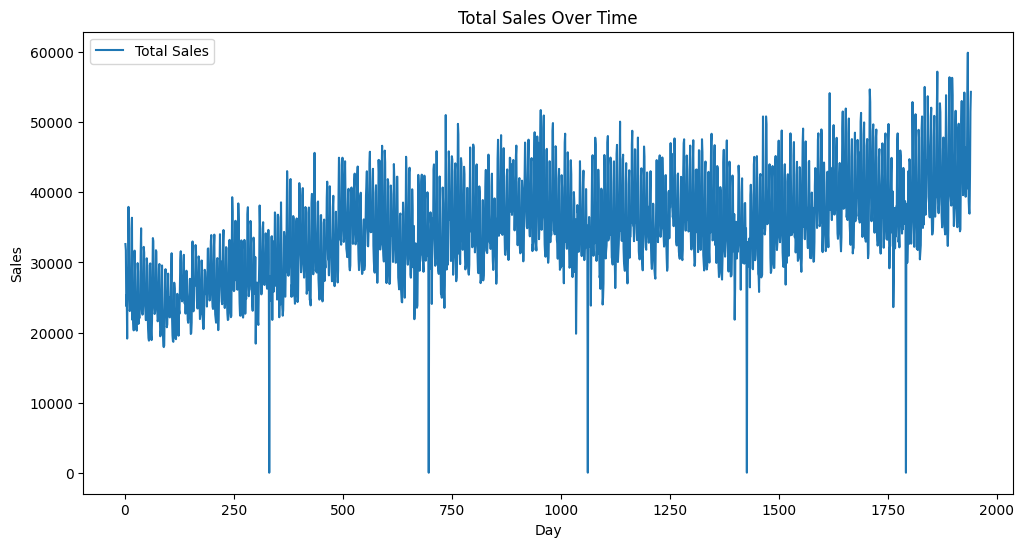

In [5]:

# Total sales over time
sales_over_time = data_long.groupby("day")["sales"].sum()
plt.figure(figsize=(12, 6))
plt.plot(sales_over_time, label="Total Sales")
plt.title("Total Sales Over Time")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.show()


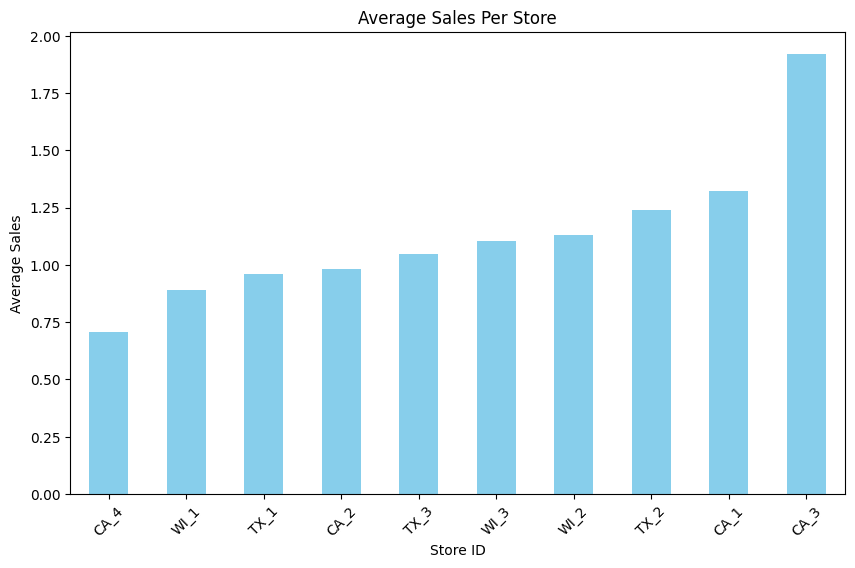

In [6]:

# Average sales per store
avg_sales_per_store = data_long.groupby("store_id")["sales"].mean().sort_values()
plt.figure(figsize=(10, 6))
avg_sales_per_store.plot(kind="bar", color="skyblue")
plt.title("Average Sales Per Store")
plt.xlabel("Store ID")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()


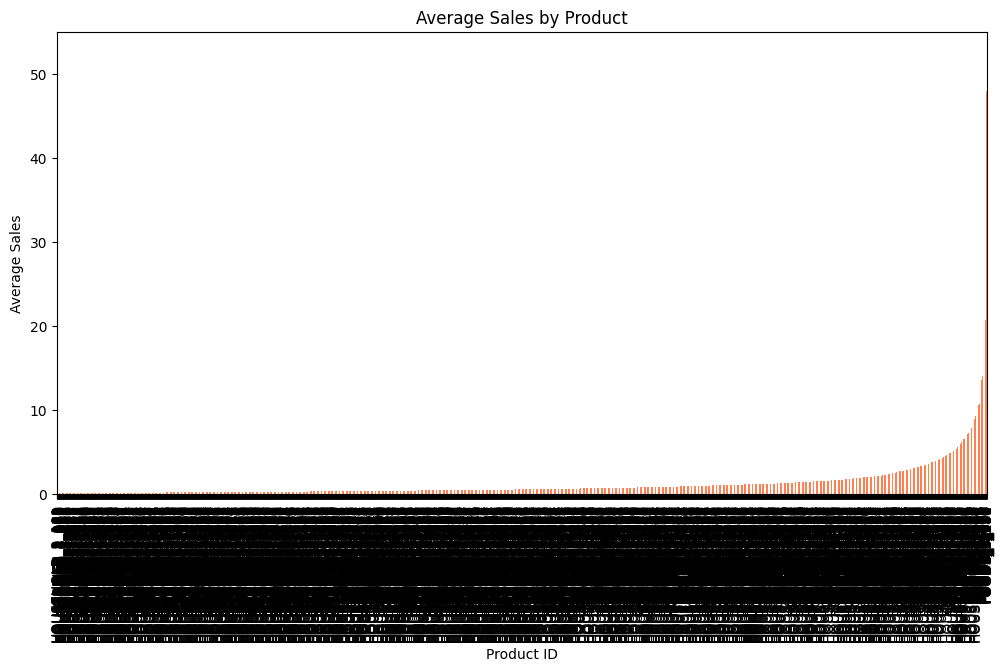

In [7]:
# Average sales by product
average_product_sales = data_long.groupby("item_id")["sales"].mean().sort_values()
plt.figure(figsize=(12, 6))
average_product_sales.plot(kind="bar", color="coral")
plt.title("Average Sales by Product")
plt.xlabel("Product ID")
plt.ylabel("Average Sales")
plt.xticks(rotation=90)
plt.show()

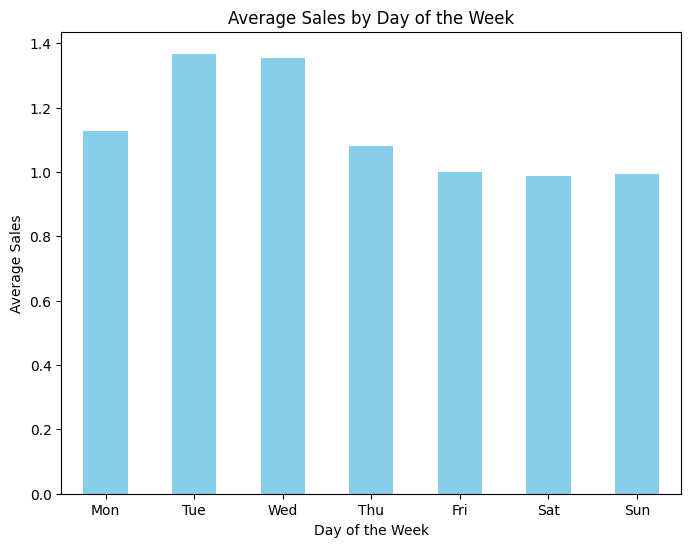

In [8]:
# Weekly seasonality
weekly_sales = data_long.groupby(data_long["day"] % 7)["sales"].mean()  # Assuming day 1 is Monday
plt.figure(figsize=(8, 6))
weekly_sales.plot(kind="bar", color="skyblue")
plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Sales")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
plt.show()

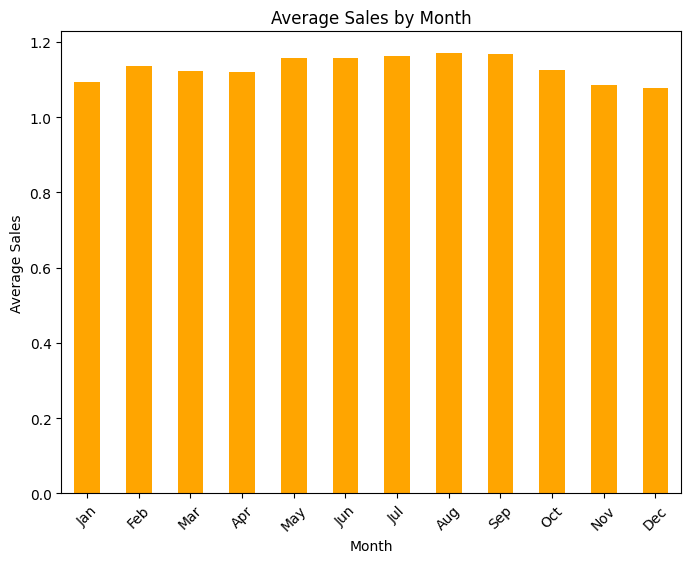

In [9]:
# Monthly seasonality
monthly_sales = data_long.groupby((data_long["day"] // 30) % 12)["sales"].mean()  # Approximate month
plt.figure(figsize=(8, 6))
monthly_sales.plot(kind="bar", color="orange")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(ticks=range(12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
plt.show()

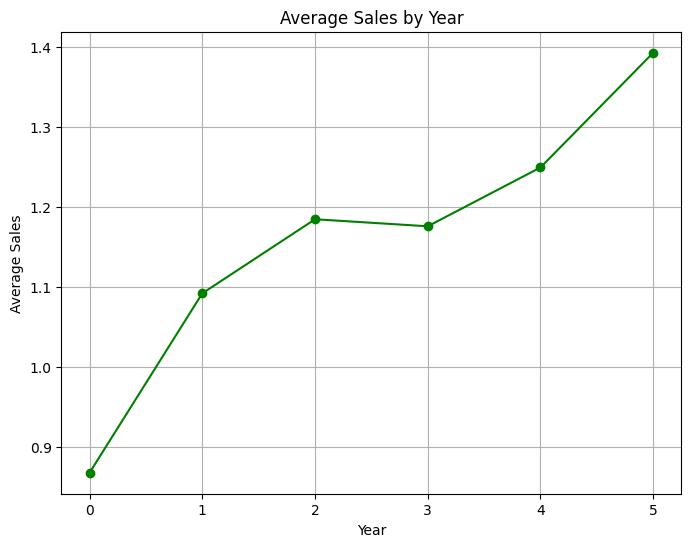

In [10]:

# Yearly seasonality
yearly_sales = data_long.groupby(data_long["day"] // 365)["sales"].mean()  # Assuming a year has 365 days
plt.figure(figsize=(8, 6))
yearly_sales.plot(kind="line", marker="o", color="green")
plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.grid()
plt.show()